# 01. Data preprocessing

Mục tiêu: đọc 3 bảng dữ liệu, làm sạch từng bảng riêng, kiểm tra missing/outlier, thống kê mô tả và vẽ histogram/boxplot cho các biến chính.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from preprocess_clean_data import (
    load_raw_data,
    clean_sales,
    clean_customer,
    clean_product,
    missing_summary,
    describe_numeric,
    iqr_outlier_summary,
    save_clean_data,
)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)

## 1. Đọc dữ liệu

In [2]:
sales_raw, customer_raw, product_raw = load_raw_data(RAW_DIR)

print("sales_data:", sales_raw.shape)
print("customer_info:", customer_raw.shape)
print("product_info:", product_raw.shape)

sales_data: (3000, 10)
customer_info: (500, 6)
product_info: (30, 6)


In [3]:
sales_raw.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-25,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-25,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,06-07-25,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,06-07-25,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,06-07-25,DELAYED,Credit Card,West,0.20


## 2. Kiểm tra missing values trước khi clean

In [4]:
raw_tables = {
    "sales": sales_raw,
    "customer": customer_raw,
    "product": product_raw,
}

missing_before = missing_summary(raw_tables)
missing_before[missing_before["missing_count"] > 0].sort_values(["table", "missing_count"], ascending=[True, False])

,table,column,missing_count,missing_rate
11,customer,email,6,0.0120
12,customer,signup_date,4,0.0080
13,customer,gender,4,0.0080
10,customer,customer_id,3,0.0060
14,customer,region,3,0.0060
15,customer,loyalty_tier,2,0.0040
9,sales,discount_applied,517,0.1723
2,sales,product_id,5,0.0017
3,sales,quantity,3,0.0010
5,sales,order_date,3,0.0010


## 3. Làm sạch dữ liệu

Các xử lý chính:
- chuẩn hóa text/categorical: viết hoa-thường, khoảng trắng, lỗi chính tả;
- chuyển `quantity`, `unit_price`, `discount_applied`, `base_price` về dạng số;
- chuyển `order_date`, `signup_date`, `launch_date` về định dạng `YYYY-MM-DD`;
- bổ sung missing values bằng median/mode hoặc `Unknown` tùy kiểu dữ liệu.


In [5]:
sales_clean = clean_sales(sales_raw)
customer_clean = clean_customer(customer_raw)
product_clean = clean_product(product_raw)

clean_tables = {
    "sales": sales_clean,
    "customer": customer_clean,
    "product": product_clean,
}

print("sales_clean:", sales_clean.shape)
print("customer_clean:", customer_clean.shape)
print("product_clean:", product_clean.shape)

sales_clean: (3000, 10)
customer_clean: (500, 6)
product_clean: (30, 6)


## 4. Kiểm tra missing values sau khi clean

In [6]:
missing_after = missing_summary(clean_tables)
missing_after[missing_after["missing_count"] > 0]

,table,column,missing_count,missing_rate


## 5. Thống kê mô tả cho biến định lượng

In [7]:
summary_stats = describe_numeric(clean_tables)
summary_stats

,table,column,count,mean,std,min,25%,50%,75%,max
0,sales,quantity,3000.0,3.003000,1.407475,1.00,2.0000,3.00,4.000,5.00
1,sales,unit_price,3000.0,28.945283,12.083880,8.00,18.8350,28.63,39.635,49.99
2,sales,discount_applied,3000.0,0.100217,0.063669,0.00,0.0500,0.10,0.150,0.20
3,product,base_price,30.0,22.844333,10.269165,6.08,14.8125,23.23,31.745,39.21


## 6. Kiểm tra outlier bằng IQR

Outlier chỉ được kiểm tra và ghi nhận. Không xóa outlier trong bước này để tránh làm mất dữ liệu hợp lệ.

In [8]:
outliers = iqr_outlier_summary(clean_tables)
outliers

,table,column,lower_bound,upper_bound,outlier_count
0,sales,quantity,-1.0000,7.0000,0
1,sales,unit_price,-12.3650,70.8350,0
2,sales,discount_applied,-0.1000,0.3000,0
3,product,base_price,-10.5862,57.1437,0


## 7. Histogram cho các biến chính

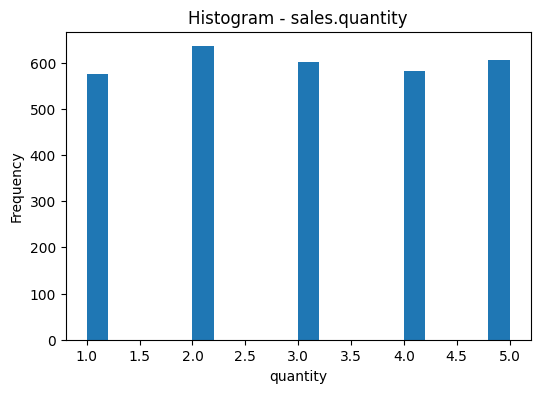

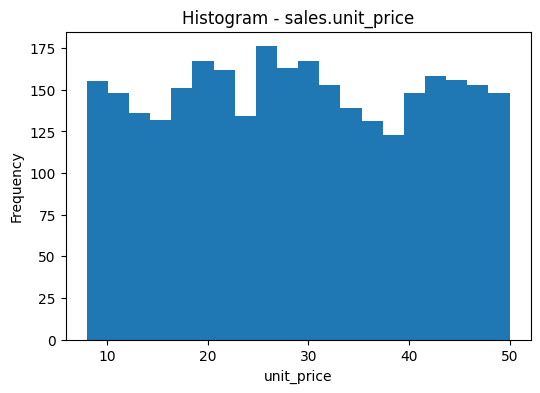

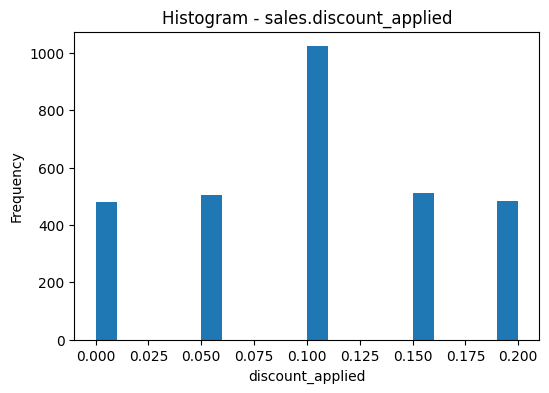

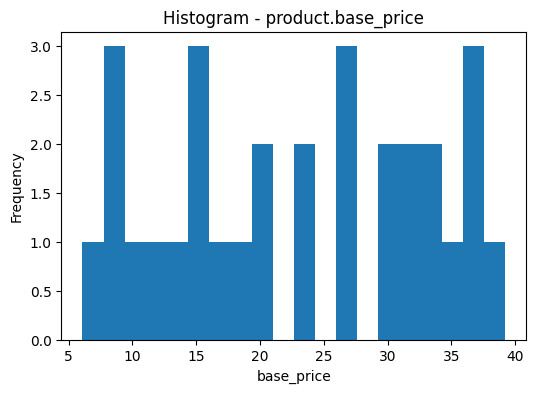

In [9]:
plot_items = [
    (sales_clean, "sales", "quantity"),
    (sales_clean, "sales", "unit_price"),
    (sales_clean, "sales", "discount_applied"),
    (product_clean, "product", "base_price"),
]

for df, table_name, column in plot_items:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column].dropna(), bins=20)
    plt.title(f"Histogram - {table_name}.{column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

## 8. Boxplot cho các biến chính

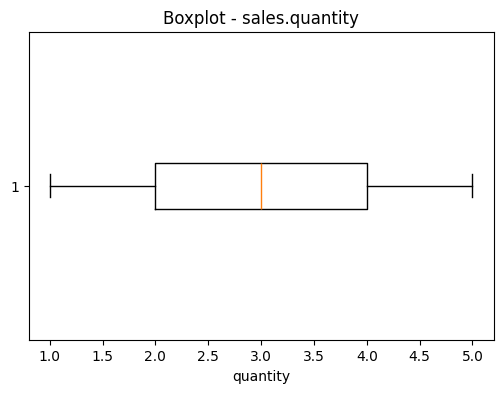

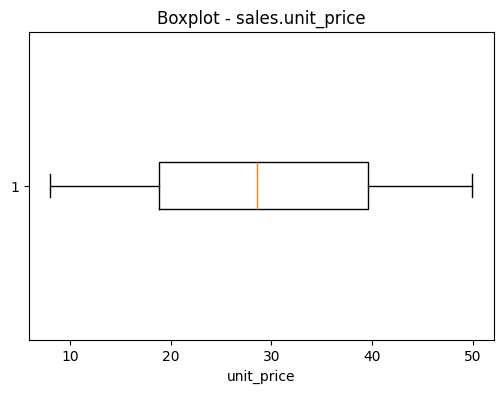

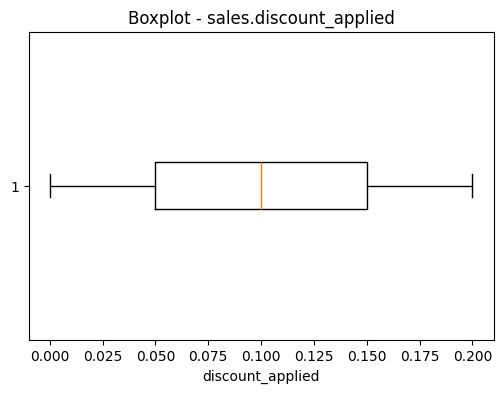

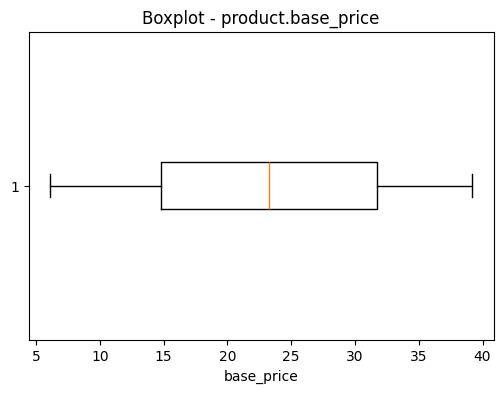

In [10]:
for df, table_name, column in plot_items:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Boxplot - {table_name}.{column}")
    plt.xlabel(column)
    plt.show()

## 9. Xuất dữ liệu đã clean

In [11]:
save_clean_data(sales_clean, customer_clean, product_clean, OUTPUT_DIR)

for file_path in sorted(OUTPUT_DIR.glob("cleaned_*.csv")):
    print(file_path.relative_to(PROJECT_ROOT))

data/processed/cleaned_customer_info.csv
data/processed/cleaned_product_info.csv
data/processed/cleaned_sales_data.csv
